In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
tickers= ["AAPL", "MSFT", "NVDA", "AMZN", "JPM"]
data= yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True)
data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN         JPM        MSFT       NVDA   
Date                                                                    
2021-01-04  125.632500  159.331497  109.000526  207.565384  13.046195   
2021-01-05  127.185753  160.925507  109.593643  207.765594  13.335955   
2021-01-06  122.904518  156.919006  114.739670  202.378403  12.549756   
2021-01-07  127.098442  158.108002  118.507652  208.137466  13.275514   
2021-01-08  128.195435  159.134995  118.638489  209.405594  13.208608   

Price             High                                                 ...  \
Ticker            AAPL        AMZN         JPM        MSFT       NVDA  ...   
Date                                                                   ...   
2021-01-04  129.709898  163.600006  110.723819  212.628417  13.582429  ...   
2021-01-05  127.894455  161.169006  110.160583  208.356769  13.374505  ...   
2021-01-06  127.224626  159.875504  115.803771  206.421209  13.177020  ...   
2021-01-07  127.787724  160.427002  120.531194  209.138635  13.309091  ...   
2021-01-08  128.758506  159.531998  118.926321  210.320951  13.352117  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN         JPM        MSFT       NVDA   
Date                                                                    
2021-01-04  129.622529  163.500000  110.412067  212.180275  13.036993   
2021-01-05  125.127641  158.300507  109.017979  207.155361  13.032520   
2021-01-06  123.991828  157.324005  113.283075  202.302122  13.154635   
2021-01-07  124.613171  157.850006  118.350660  204.085131  12.900946   
2021-01-08  128.564332  159.000000  118.594875  208.509310  13.293918   

Price          Volume                                           
Ticker           AAPL      AMZN       JPM      MSFT       NVDA  
Date                                                            
2021-01-04  143301900  88228000  16819900  37130100  560640000  
2021-01-05   97664900  53110000  13731200  23823000  322760000  
2021-01-06  155088000  87896000  24909100  35930700  580424000  
2021-01-07  109578200  70290000  21940400  27694500  461480000  
2021-01-08  105158200  70754000  12035100  22956200  292528000  

[5 rows x 25 columns]

In [2]:
data.shape
data.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close',  'JPM'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High',  'JPM'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low',  'JPM'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open',  'JPM'),
            (  'Open', 'MSFT'),
            (  'Open', 'NVDA'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume',  'JPM'),
            ('Volume', 'MSFT'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [3]:
prices= data["Close"]
prices.head()

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Date,,,,,
2021-01-04,125.632500,159.331497,109.000526,207.565384,13.046195
2021-01-05,127.185753,160.925507,109.593643,207.765594,13.335955
2021-01-06,122.904518,156.919006,114.739670,202.378403,12.549756
2021-01-07,127.098442,158.108002,118.507652,208.137466,13.275514
2021-01-08,128.195435,159.134995,118.638489,209.405594,13.208608


In [4]:
# Calculate daily returns to measure the percentage change in each stock's price from one trading day to the next.
# Returns provide more insight than raw prices when comparing stock performance.
returns= prices.pct_change()
returns= returns.dropna()
returns.head()

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Date,,,,,
2021-01-05,0.012363,0.010004,0.005441,0.000965,0.022210
2021-01-06,-0.033661,-0.024897,0.046956,-0.025929,-0.058953
2021-01-07,0.034123,0.007577,0.032839,0.028457,0.057830
2021-01-08,0.008631,0.006496,0.001104,0.006093,-0.005040
2021-01-11,-0.023249,-0.021519,0.014924,-0.009699,0.025967


In [5]:
# Average daily return for each stock
mean_returns= returns. mean() * 100
mean_returns.round(2)

Ticker
AAPL    0.08
AMZN    0.05
JPM     0.10
MSFT    0.08
NVDA    0.27
dtype: float64

In [6]:
# Daily volatility
volatility= returns.std()
volatility_pct= returns.std() * 100
volatility_pct.round(2)

Ticker
AAPL    1.76
AMZN    2.21
JPM     1.53
MSFT    1.62
NVDA    3.29
dtype: float64

In [7]:
summary = pd.DataFrame({
    "Mean Daily Return (%)": mean_returns,
    "Daily Volatility (%)": volatility_pct
})
summary.round(2)

,Mean Daily Return (%),Daily Volatility (%)
Ticker,,
AAPL,0.08,1.76
AMZN,0.05,2.21
JPM,0.10,1.53
MSFT,0.08,1.62
NVDA,0.27,3.29


In [8]:
# Annualized average daily return (252 trading days per year)
annual_return = mean_returns * 252
annual_return.round(2)

Ticker
AAPL    19.32
AMZN    13.60
JPM     24.45
MSFT    20.17
NVDA    66.95
dtype: float64

In [9]:
# Annualized daily volatility
annual_volatility = volatility * np.sqrt(252)
annual_volatility_pct= annual_volatility * 100
annual_volatility_pct.round(2)

Ticker
AAPL    27.86
AMZN    35.11
JPM     24.27
MSFT    25.71
NVDA    52.22
dtype: float64

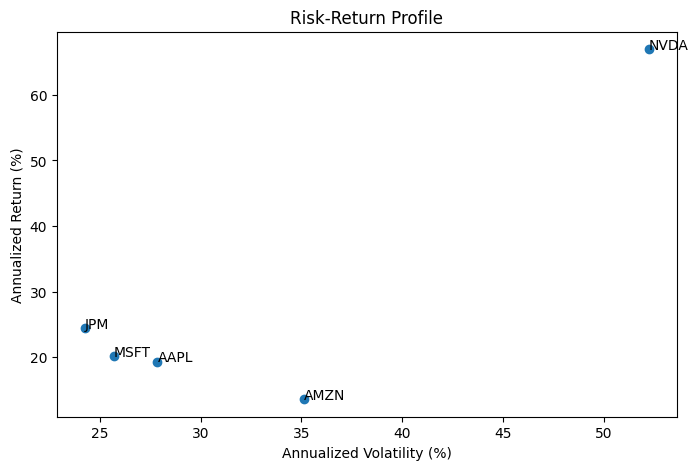

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(
annual_volatility_pct,
annual_return
)
for ticker in tickers:
    plt.annotate(
        ticker,
        (
            annual_volatility_pct[ticker],
            annual_return[ticker]
        )
    )
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk-Return Profile")
plt.show()

In [11]:
# Stock correlation measures how closely the returns of two different stocks
# move in relation to one another on a scale from -1.0 to +1.0,
# while Covariance measures the directional relationship between the returns of two stocks
# to determine whether they move together or in opposite directions.
correlation = returns.corr()
correlation.round(2)

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Ticker,,,,,
AAPL,1.00,0.56,0.35,0.63,0.52
AMZN,0.56,1.00,0.34,0.65,0.56
JPM,0.35,0.34,1.00,0.31,0.32
MSFT,0.63,0.65,0.31,1.00,0.63
NVDA,0.52,0.56,0.32,0.63,1.00


In [12]:
covariance = returns.cov()
covariance.round(6)

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Ticker,,,,,
AAPL,0.000308,0.000218,0.000093,0.000180,0.000300
AMZN,0.000218,0.000489,0.000116,0.000235,0.000405
JPM,0.000093,0.000116,0.000234,0.000077,0.000159
MSFT,0.000180,0.000235,0.000077,0.000262,0.000336
NVDA,0.000300,0.000405,0.000159,0.000336,0.001082


In [13]:
# Scenario 1: Equal-weighted portfolio
weights= np.array([0.2, 0.2, 0.2, 0.2, 0.2])
# Portfolio Return = Σ (Stock Return * Stock Weight)
portfolio_returns = returns.dot(weights) 
portfolio_returns.head()

Date
2021-01-05    0.010197
2021-01-06   -0.019297
2021-01-07    0.032165
2021-01-08    0.003457
2021-01-11   -0.002715
dtype: float64

In [14]:
# The average daily return of the portfolio/ Annualized
portfolio_mean_returns= portfolio_returns.mean()
annual_portfolio_return= portfolio_mean_returns * 252
print(f"Mean Daily Portfolio Return: {portfolio_mean_returns:.4%}")
print(f"Annualized Portfolio Return: {annual_portfolio_return:.2%}")

Mean Daily Portfolio Return: 0.1147%
Annualized Portfolio Return: 28.90%


In [15]:
# Daily Portfolio Volatility/ Annualized
portfolio_volatility = portfolio_returns.std()
annual_portfolio_volatility= portfolio_volatility * np.sqrt(252)
print(f"Daily Portfolio Volatility: {portfolio_volatility:.4%}")
print(f"Annualized Portfolio Volatility: {annual_portfolio_volatility:.2%}")

Daily Portfolio Volatility: 1.6265%
Annualized Portfolio Volatility: 25.82%


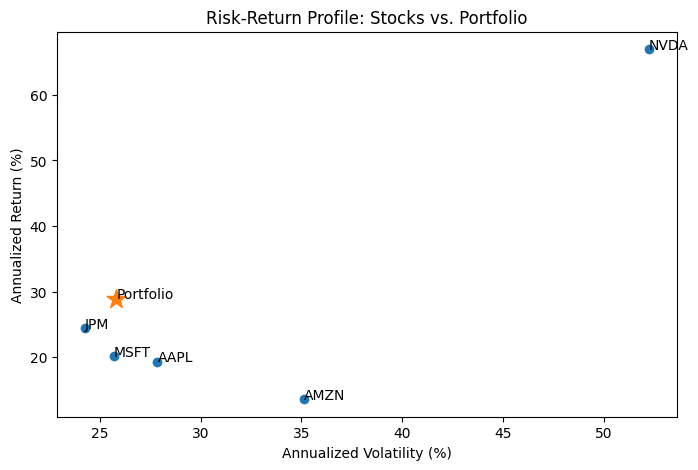

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(
    annual_volatility_pct,
    annual_return
)
for ticker in tickers:
    plt.annotate(
        ticker,
        (
            annual_volatility_pct[ticker],
            annual_return[ticker]
        )
    )
# Add the equal-weighted portfolio to the risk-return plot.
plt.scatter(
    annual_portfolio_volatility * 100,
    annual_portfolio_return * 100,
    marker="*",
    s=200
)
plt.annotate(
    "Portfolio",
    (
        annual_portfolio_volatility * 100,
        annual_portfolio_return * 100
    )
)
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk-Return Profile: Stocks vs. Portfolio")
plt.show()

Analysis of Results

The analysis shows that the five stocks have different risk–return characteristics, with differences in both their average returns and volatility. This highlights the importance of considering risk alongside return when evaluating individual assets.

The correlation and covariance matrices also show that the stocks do not move perfectly together. This imperfect co-movement is important from a portfolio management perspective because combining assets with less-than-perfect correlation can help reduce portfolio-level risk.

The equal-weighted portfolio provides a simple illustration of this diversification effect. Rather than depending on the performance of a single stock, the portfolio combines the return characteristics of all five assets. Its overall risk and return therefore reflect both the individual characteristics of the stocks and their relationships with one another.

The risk–return visualization makes these relationships easier to interpret. It provides a more intuitive way to understand portfolio concepts that can otherwise remain abstract when expressed only through mathematical formulas and numerical tables.

However, the equal-weighted portfolio is only a starting point. Equal weights are not necessarily optimal from a risk-adjusted return perspective. The next stage of the project will therefore focus on portfolio optimization, including the efficient frontier and Sharpe ratio, to investigate how different portfolio weights can affect the risk–return profile.